In [1]:
from totalsegmentator.python_api import totalsegmentator
import SimpleITK as sitk, nibabel as nib
import numpy as np, os
from dicom2nifti.common import ConversionValidationError  # to catch that specific error

# ════════════════════════════════════════════════════════════════════════════════
# 📁 PARENT FOLDER CONTAINING MULTIPLE DICOM SUBFOLDERS
# ════════════════════════════════════════════════════════════════════════════════

parent_dir = r"D:\Abdomen_CT_Bone_Mets"
pelvis_labels = ["hip_left", "hip_right"]
lung_labels   = [
    "lung_upper_lobe_left",
    "lung_lower_lobe_left",
    "lung_upper_lobe_right",
    "lung_middle_lobe_right",
    "lung_lower_lobe_right"
]

# Sort subfolders by their trailing numeric part (e.g., BMAB1_00000001 → 1, BMAB1_00000002 → 2, etc.)
def sort_key(name):
    try:
        return int(name.split("_")[-1])
    except ValueError:
        return name  # fallback for nonmatching names

for subfolder in sorted(os.listdir(parent_dir), key=sort_key):
    dicom_dir = os.path.join(parent_dir, subfolder)
    if not os.path.isdir(dicom_dir):
        continue

    print(f"\n🔄 Processing folder: {dicom_dir}")

    # ─────────── Output folders and combined‐mask paths ───────────
    pelvis_out_dir = os.path.join(dicom_dir, "_seg_pelvis")
    lung_out_dir   = os.path.join(dicom_dir, "_seg_lung")

    pelvis_combined_f = os.path.join(pelvis_out_dir, "hips_combined.nii.gz")
    lung_combined_f   = os.path.join(lung_out_dir,   "lungs_combined.nii.gz")

    # If both combined outputs already exist, skip entire folder
    if os.path.exists(pelvis_combined_f) and os.path.exists(lung_combined_f):
        print(f"ℹ️  Skipping {subfolder}: combined outputs already exist.")
        continue

    # ─────── Helper: attempt segmentation on DICOM, else fallback to a SITK‐converted NIfTI ───────
    def run_totalseg_on(input_path, out_dir, labels):
        """
        Try totalsegmentator(input_path), and if a ConversionValidationError is raised,
        convert `input_path` (a DICOM folder) to a temporary NIfTI via SimpleITK, then re‐run totalseg.
        Returns nothing, but ensures that `out_dir/<label>.nii.gz` exists for each label.
        """
        try:
            totalsegmentator(
                input_path, out_dir,
                roi_subset=labels,
                fast=True,
                nr_thr_resamp=1, nr_thr_saving=1,
                device="gpu"
            )
        except ConversionValidationError:
            # 1) Convert DICOM folder → NIfTI using SITK
            print(f"⚠️  DICOM→NIfTI failed validation for {input_path}. Falling back to SimpleITK conversion.")
            reader = sitk.ImageSeriesReader()
            reader.SetFileNames(reader.GetGDCMSeriesFileNames(input_path))
            ct_itk = reader.Execute()
            # Write out a temporary NIfTI in the same folder
            nifti_tmp = os.path.join(input_path, "ct_converted.nii.gz")
            sitk.WriteImage(ct_itk, nifti_tmp)
            # 2) Run totalsegmentator on that NIfTI file
            totalsegmentator(
                nifti_tmp, out_dir,
                roi_subset=labels,
                fast=True,
                nr_thr_resamp=1, nr_thr_saving=1,
                device="gpu"
            )
            # Optionally remove the temporary NIfTI:
            os.remove(nifti_tmp)

    # ────────────── BLOCK 1A: Pelvis segmentation + combine hips ──────────────
    if not os.path.exists(pelvis_combined_f):
        os.makedirs(pelvis_out_dir, exist_ok=True)
        run_totalseg_on(dicom_dir, pelvis_out_dir, pelvis_labels)

        mask_combined = None
        for lab in pelvis_labels:
            fpath = os.path.join(pelvis_out_dir, f"{lab}.nii.gz")
            img   = nib.load(fpath)
            data  = img.get_fdata().astype(bool)

            if mask_combined is None:
                mask_combined = data
                affine, header = img.affine, img.header
            else:
                mask_combined |= data

        nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), pelvis_combined_f)
        print("✅ Pelvis combined NIfTI saved ➜", pelvis_combined_f)
    else:
        print(f"ℹ️  {subfolder}: hips_combined.nii.gz already exists, skipping pelvis block.")

    # ────────────── BLOCK 1B: Lung segmentation + combine lobes ──────────────
    if not os.path.exists(lung_combined_f):
        os.makedirs(lung_out_dir, exist_ok=True)
        run_totalseg_on(dicom_dir, lung_out_dir, lung_labels)

        mask_combined = None
        for lab in lung_labels:
            fpath = os.path.join(lung_out_dir, f"{lab}.nii.gz")
            img   = nib.load(fpath)
            data  = img.get_fdata().astype(bool)

            if mask_combined is None:
                mask_combined = data
                affine, header = img.affine, img.header
            else:
                mask_combined |= data

        nib.save(nib.Nifti1Image(mask_combined.astype(np.uint8), affine, header), lung_combined_f)
        print("✅ Lung mask combined ➜", lung_combined_f)
    else:
        print(f"ℹ️  {subfolder}: lungs_combined.nii.gz already exists, skipping lung block.")


🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB1_00000001
ℹ️  Skipping BMAB1_00000001: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000001
ℹ️  Skipping BMAB2_00000001: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB3_00000001
ℹ️  Skipping BMAB3_00000001: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB1_00000002
ℹ️  Skipping BMAB1_00000002: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000002
ℹ️  Skipping BMAB2_00000002: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB3_00000002
ℹ️  Skipping BMAB3_00000002: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB1_00000003
ℹ️  Skipping BMAB1_00000003: combined outputs already exist.

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000003
ℹ️  Skipping BMAB2_00000003: combined outputs already exist.

🔄 Processing folder: D:

100%|██████████| 8/8 [00:00<00:00, 28.35it/s]


  Predicted in 6.61s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 727)
  cropping from (512, 512, 727) to (348, 241, 163)
Resampling...
  Resampled in 0.34s
Predicting...


100%|██████████| 1/1 [00:00<00:00,  1.36it/s]


  Predicted in 6.84s
Resampling...
Saving segmentations...
  Saved in 7.30s
✅ Lung mask combined ➜ D:\Abdomen_CT_Bone_Mets\BMAB2_00000007\_seg_lung\lungs_combined.nii.gz

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB3_00000007

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...
  found image with shape (512, 512, 911)
Resampling...
  Resampled in 6.17s
Predicting...


...

100%|██████████| 8/8 [00:00<00:00, 36.79it/s]


  Predicted in 6.32s
Resampling...
Converting dicom to nifti...
  found image with shape (512, 512, 866)
  cropping from (512, 512, 866) to (354, 254, 229)
Resampling...
  Resampled in 0.48s
Predicting...


100%|██████████| 1/1 [00:00<00:00, 129.99it/s]


  Predicted in 6.31s
Resampling...
Saving segmentations...
  Saved in 6.40s
✅ Lung mask combined ➜ D:\Abdomen_CT_Bone_Mets\BMAB1_00000016\_seg_lung\lungs_combined.nii.gz

🔄 Processing folder: D:\Abdomen_CT_Bone_Mets\BMAB2_00000016

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Using 'fast' option: resampling to lower resolution (3mm)
Generating rough segmentation for cropping...
Converting dicom to nifti...


KeyboardInterrupt: 

In [11]:
import os
import SimpleITK as sitk
import numpy as np
import pandas as pd

# ────────────────────────────────────────────────────────────────────────────────
# 🗂️  Adjust this “root_dir” to point at:
#     D:\Abdomen_CT_Bone_Mets
# ────────────────────────────────────────────────────────────────────────────────
root_dir = r"D:\Abdomen_CT_Bone_Mets"

# ────────────────────────────────────────────────────────────────────────────────
# 📝  Constants
#     – allowance_mm is still 30 mm in both directions
#     – mask filenames are assumed to be exactly:
#         lungs_combined.nii (or .nii.gz)
#         hips_combined.nii   (or .nii.gz)
# ────────────────────────────────────────────────────────────────────────────────
allowance_mm     = 30.0
lung_mask_name   = "lungs_combined"
pelvis_mask_name = "hips_combined"

# ────────────────────────────────────────────────────────────────────────────────
# 🔍  Helper: find a file named “<base>.(nii or nii.gz)” under a given directory
# ────────────────────────────────────────────────────────────────────────────────
def find_mask_file(folder, base_name):
    """
    Looks for either base_name.nii or base_name.nii.gz inside `folder`.
    Returns the full path if found, otherwise returns None.
    """
    candidates = [f"{base_name}.nii", f"{base_name}.nii.gz"]
    for fn in candidates:
        path = os.path.join(folder, fn)
        if os.path.isfile(path):
            return path
    return None

# ────────────────────────────────────────────────────────────────────────────────
# 📊  Prepare a list to collect results (will convert into DataFrame later)
# ────────────────────────────────────────────────────────────────────────────────
results = []

# ────────────────────────────────────────────────────────────────────────────────
# 🚀  Loop through each patient subfolder in root_dir
# ────────────────────────────────────────────────────────────────────────────────
for patient_id in os.listdir(root_dir):
    patient_dir = os.path.join(root_dir, patient_id)
    if not os.path.isdir(patient_dir):
        continue

    # Expecting two subfolders inside each patient folder:
    #   _seg_lung      (contains lungs_combined.nii or .nii.gz)
    #   _seg_pelvis    (contains hips_combined.nii or .nii.gz)
    lung_seg_dir   = os.path.join(patient_dir, "_seg_lung")
    pelvis_seg_dir = os.path.join(patient_dir, "_seg_pelvis")

    # Check that both exist
    if not (os.path.isdir(lung_seg_dir) and os.path.isdir(pelvis_seg_dir)):
        print(f"→ Skipping {patient_id}: missing _seg_lung or _seg_pelvis folder")
        continue

    # Find the actual mask files (handle either .nii or .nii.gz)
    lung_mask_f   = find_mask_file(lung_seg_dir,   lung_mask_name)
    pelvis_mask_f = find_mask_file(pelvis_seg_dir, pelvis_mask_name)

    if lung_mask_f is None or pelvis_mask_f is None:
        print(f"→ Skipping {patient_id}: could not find mask files in subfolders")
        continue

    # We’ll assume the DICOM series for CT is directly under patient_dir.
    dicom_dir = patient_dir

    print("\n" + "─" * 80)
    print(f"📂 Processing patient: {patient_id}")

    try:
        # ────────────────────────────────────────────────────────────────────────────
        # 📦 Load CT & Reorient to RAS
        # ────────────────────────────────────────────────────────────────────────────
        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(reader.GetGDCMSeriesFileNames(dicom_dir))
        ct_itk = reader.Execute()

        # Reorient CT into strict RAS (so that +Z in index → physically “up” / cranial)
        orienter = sitk.DICOMOrientImageFilter()
        orienter.SetDesiredCoordinateOrientation("RAS")
        ct_ras = orienter.Execute(ct_itk)

        # Grab CT spacing and size (needed to map Z → slice index)
        spacing_ct = ct_ras.GetSpacing()     # (spacing_x, spacing_y, spacing_z)
        size_ct    = ct_ras.GetSize()        # (size_x, size_y, size_z)
        z_dim_ct   = size_ct[2]
        spacing_ct_z = spacing_ct[2]         # slice thickness in mm

        # Compute “bottom” and “top” Z in CT’s physical space:
        phys_z_0    = ct_ras.TransformIndexToPhysicalPoint((0, 0, 0))[2]
        phys_z_last = ct_ras.TransformIndexToPhysicalPoint((0, 0, z_dim_ct - 1))[2]
        bottom_phys_z = min(phys_z_0, phys_z_last)
        top_phys_z    = max(phys_z_0, phys_z_last)

        # ────────────────────────────────────────────────────────────────────────────
        # 🫁 Diaphragm Detection (Cranial Overscan) via mask‐space → CT‐space
        # ────────────────────────────────────────────────────────────────────────────
        # 1) Read lung mask, reorient it to RAS (so axes line up with CT), but do NOT resample
        mask_lung_itk = sitk.ReadImage(lung_mask_f)
        mask_lung_ras = orienter.Execute(mask_lung_itk)
        mask_np_lung  = sitk.GetArrayFromImage(mask_lung_ras).astype(bool)
        #    mask_np_lung.shape == (mask_z, mask_y, mask_x)

        # 2) Find which mask‐slices (in mask_z) contain any lung voxel
        lung_z_indices = np.where(mask_np_lung.any(axis=(1, 2)))[0]
        if lung_z_indices.size == 0:
            raise RuntimeError("No lung voxels found → cannot locate diaphragm.")

        # 3) For each candidate z in lung_z_indices, compute that slice's physical Z:
        #    (mask_ras.TransformIndexToPhysicalPoint((0,0,z))[2]) is the physical Z of that slice.
        phys_z_list = [
            mask_lung_ras.TransformIndexToPhysicalPoint((0, 0, int(z_idx)))[2]
            for z_idx in lung_z_indices
        ]
        # 4) Pick the slice with the *maximum* physical Z (i.e. “most inferior lung slice”)
        arg_max  = int(np.argmax(phys_z_list))
        mask_z_diaphragm = int(lung_z_indices[arg_max])
        diaphragm_phys_z = phys_z_list[arg_max]

        # 5) Convert that physical Z into a CT‐slice index:
        #    (distance from CT bottom) ÷ (CT slice thickness), rounded to nearest slice.
        diaphragm_ct_z = int(round((diaphragm_phys_z - bottom_phys_z) / spacing_ct_z))
        # Clamp in [0, z_dim_ct – 1], just in case small numerical drift:
        diaphragm_ct_z = max(0, min(z_dim_ct - 1, diaphragm_ct_z))

        # 6) Compute how far (in mm) this diaphragm_phys_z is below CT’s top:
        distance_above_mm    = top_phys_z - diaphragm_phys_z
        overscan_mm_cranial  = max(0.0, distance_above_mm - allowance_mm)

        print(f"🫁 Diaphragm (mask‐slice)           = {mask_z_diaphragm}")
        print(f"🫁 Diaphragm (CT‐slice)            = {diaphragm_ct_z}")
        print(f"📏 Distance above diaphragm        = {distance_above_mm:.1f} mm")
        if overscan_mm_cranial <= 0:
            print("✅ No cranial overscan (within 30 mm allowance).")
        else:
            slices_over = overscan_mm_cranial / spacing_ct_z
            print(
                f"⚠️  Cranial overscan               = {overscan_mm_cranial:.1f} mm "
                f"(≈ {slices_over:.1f} slices)"
            )

        # ────────────────────────────────────────────────────────────────────────────
        # 🦴 Pubic Symphysis Detection (Caudal Overscan)
        # ────────────────────────────────────────────────────────────────────────────
        # 1) Read pelvis mask, reorient it to RAS, but DO NOT resample
        mask_pelvis_itk = sitk.ReadImage(pelvis_mask_f)
        mask_pelvis_ras = orienter.Execute(mask_pelvis_itk)
        mask_np_pelvis  = sitk.GetArrayFromImage(mask_pelvis_ras).astype(bool)
        #    mask_np_pelvis.shape == (mask_z_p, mask_y_p, mask_x_p)

        # 2) Find the mid‐sagittal x‐index in the mask’s RAS grid
        size_pelvis = mask_pelvis_ras.GetSize()  # (size_x_p, size_y_p, size_z_p)
        x_dim_p     = size_pelvis[0]
        mid_x       = x_dim_p // 2
        x_start     = max(0, mid_x - 2)
        x_end       = min(x_dim_p, mid_x + 3)

        # 3) For each slice z in the pelvis mask, check if any voxel appears in that 5-voxel band
        z_dim_p = size_pelvis[2]
        z_midline_hits = [
            z for z in range(z_dim_p)
            if mask_np_pelvis[z, :, x_start:x_end].any()
        ]

        if len(z_midline_hits) == 0:
            raise RuntimeError("No midline contact → symphysis not detected.")

        # 4) Compute each candidate’s physical Z (in mask RAS space):
        phys_z_p_list = [
            mask_pelvis_ras.TransformIndexToPhysicalPoint((0, 0, int(z_idx)))[2]
            for z_idx in z_midline_hits
        ]
        # 5) Pick the *minimum* physical Z (i.e. lowest pelvis midline slice = pubic symphysis)
        arg_min_p = int(np.argmin(phys_z_p_list))
        mask_z_pubis = int(z_midline_hits[arg_min_p])
        pubic_phys_z = phys_z_p_list[arg_min_p]

        # 6) Convert that pubic_phys_z into a CT‐slice index:
        pubic_ct_z = int(round((pubic_phys_z - bottom_phys_z) / spacing_ct_z))
        pubic_ct_z = max(0, min(z_dim_ct - 1, pubic_ct_z))

        # 7) Compute distance (in mm) from CT bottom up to pubic_phys_z
        distance_below_mm    = pubic_phys_z - bottom_phys_z
        overscan_mm_caudal   = max(0.0, distance_below_mm - allowance_mm)

        print(f"\n🦴 Symphysis (mask‐slice)           = {mask_z_pubis}")
        print(f"🦴 Symphysis (CT‐slice)            = {pubic_ct_z}")
        print(f"📏 Distance below symphysis        = {distance_below_mm:.1f} mm")
        if overscan_mm_caudal <= 0:
            print("✅ No caudal overscan (within 30 mm allowance).")
        else:
            slices_over = overscan_mm_caudal / spacing_ct_z
            print(
                f"⚠️  Caudal overscan                = {overscan_mm_caudal:.1f} mm "
                f"(≈ {slices_over:.1f} slices)"
            )

        # ────────────────────────────────────────────────────────────────────────────
        # 📈  Append results into the list
        # ────────────────────────────────────────────────────────────────────────────
        row = {
            "patient_id":            patient_id,
            "diaphragm_idx":         diaphragm_ct_z,
            "distance_above_mm":     distance_above_mm,
            "overscan_mm_cranial":   overscan_mm_cranial,
            "pubic_idx":             pubic_ct_z,
            "distance_below_mm":     distance_below_mm,
            "overscan_mm_caudal":    overscan_mm_caudal
        }
        results.append(row)

    except Exception as e:
        print(f"‼️  Error processing {patient_id}: {e}")
        # (Optionally, you could append a row with NaNs or skip entirely. Here we skip.)

# ────────────────────────────────────────────────────────────────────────────────
# 📋  After all patients are processed:
#     – build the DataFrame from the list
#     – print head
#     – print summary (describe)
#     – save DataFrame to CSV
# ────────────────────────────────────────────────────────────────────────────────
df = pd.DataFrame(results, columns=[
    "patient_id",
    "diaphragm_idx",
    "distance_above_mm",
    "overscan_mm_cranial",
    "pubic_idx",
    "distance_below_mm",
    "overscan_mm_caudal"
])

print("\n=== DataFrame Head ===")
print(df.head())

print("\n=== DataFrame Summary (describe) ===")
print(df.describe())

output_csv = os.path.join(root_dir, "overscan_results.csv")
df.to_csv(output_csv, index=False)
print(f"\n✅ Results saved to: {output_csv}")

→ Skipping BMAB3_00000240: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000241: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000242: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000243: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000244: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000245: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000246: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000247: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000248: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000249: missing _seg_lung or _seg_pelvis folder
→ Skipping BMAB3_00000250: missing _seg_lung or _seg_pelvis folder

────────────────────────────────────────────────────────────────────────────────
📂 Processing patient: BMAB1_00000001
🫁 Diaphragm (mask‐slice)           = 914
🫁 Diaphragm (CT‐slice)            = 914
📏 Distance above diaphragm        = 0.0 mm
✅ No cranial oversca

In [13]:
print(os.getcwd())

c:\Users\Ryan Krishna\Documents\Overscanning


=== Cranial Overscan (Lungs) ===
Total scans: 42
Scans with cranial overscan: 0
Scans without cranial overscan: 42
Average cranial overscan (among overscanned): nan mm

=== Caudal Overscan (Pubic) ===
Total scans: 42
Scans with caudal overscan: 39
Scans without caudal overscan: 3
Average caudal overscan (among overscanned): 137.19 mm



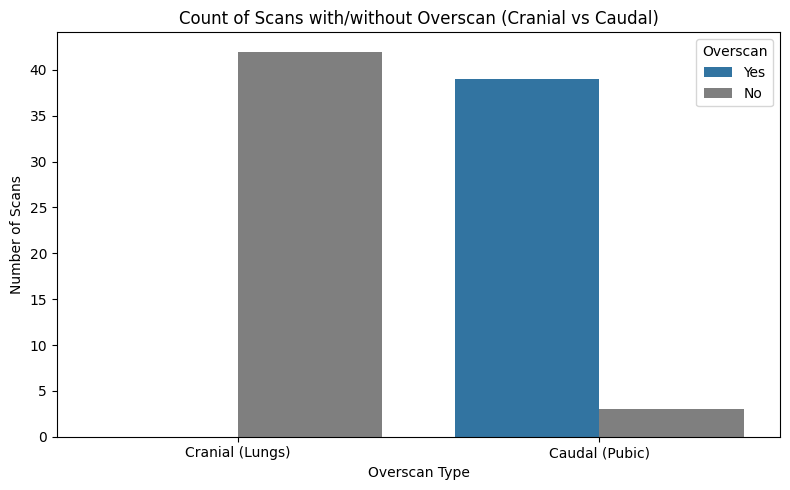

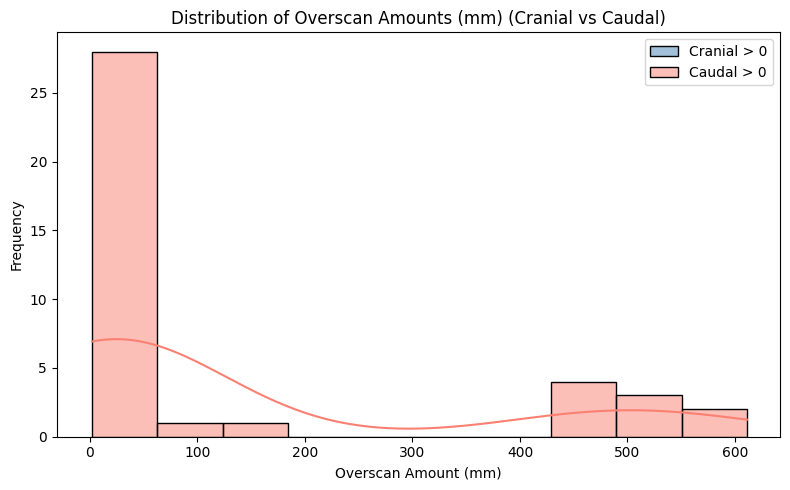

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure inline plotting
%matplotlib inline

# Load the CSV from /mnt/data
csv_path = "D:\Abdomen_CT_Bone_Mets\overscan_results.csv"
df = pd.read_csv(csv_path)

# Create boolean columns for cranial and caudal overscan
df['cranial_overscan'] = df['overscan_mm_cranial'] > 0
df['caudal_overscan'] = df['overscan_mm_caudal'] > 0

# Calculate counts and averages for cranial overscan
total_scans = len(df)
cranial_count = df['cranial_overscan'].sum()
cranial_no_count = total_scans - cranial_count
avg_cranial_overscan = df.loc[df['cranial_overscan'], 'overscan_mm_cranial'].mean()

# Calculate counts and averages for caudal overscan
caudal_count = df['caudal_overscan'].sum()
caudal_no_count = total_scans - caudal_count
avg_caudal_overscan = df.loc[df['caudal_overscan'], 'overscan_mm_caudal'].mean()

# Print summary statistics
print("=== Cranial Overscan (Lungs) ===")
print(f"Total scans: {total_scans}")
print(f"Scans with cranial overscan: {cranial_count}")
print(f"Scans without cranial overscan: {cranial_no_count}")
print(f"Average cranial overscan (among overscanned): {avg_cranial_overscan:.2f} mm\n")

print("=== Caudal Overscan (Pubic) ===")
print(f"Total scans: {total_scans}")
print(f"Scans with caudal overscan: {caudal_count}")
print(f"Scans without caudal overscan: {caudal_no_count}")
print(f"Average caudal overscan (among overscanned): {avg_caudal_overscan:.2f} mm\n")

# Plot 1: Bar chart of counts
counts_df = pd.DataFrame({
    'Type': ['Cranial (Lungs)', 'Cranial (Lungs)',
             'Caudal (Pubic)', 'Caudal (Pubic)'],
    'Overscan': ['Yes', 'No', 'Yes', 'No'],
    'Count': [cranial_count, cranial_no_count, caudal_count, caudal_no_count]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=counts_df, x='Type', y='Count', hue='Overscan', palette={'Yes':'tab:blue', 'No':'tab:gray'})
plt.title('Count of Scans with/without Overscan (Cranial vs Caudal)')
plt.ylabel('Number of Scans')
plt.xlabel('Overscan Type')
plt.legend(title='Overscan')
plt.tight_layout()
plt.show()

# Plot 2: Distribution of overscan amounts
plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['cranial_overscan']], x='overscan_mm_cranial', bins=10, kde=True, color='steelblue', label='Cranial > 0')
sns.histplot(data=df[df['caudal_overscan']], x='overscan_mm_caudal', bins=10, kde=True, color='salmon', label='Caudal > 0')
plt.title('Distribution of Overscan Amounts (mm) (Cranial vs Caudal)')
plt.xlabel('Overscan Amount (mm)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()